# Act 4 — The City as a Signal

At scale, individual trips stop mattering. The system begins to move as a whole.

Peaks, drops, repetitions, breaks — all possible observations. What seemed like randomness now hints at structure. But structure is deceptive: some patterns are real, others are artifacts of how you choose to observe them.

**Task:** Aggregate trips meaningfully, then decide:
- Which patterns persist?
- Which disappear?
- Which were never there to begin with?

Determine whether the city's rhythm is **stable**, **cyclical**, or simply **noise that looks convincing**.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.signal import periodogram

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_STABILITY='#2ecc71'; COLOR_STRESS='#e74c3c'
COLOR_CAUTION='#f39c12'; COLOR_NEUTRAL='#3498db'
FIGURES_DIR='figures'; DATA_DIR='data'
os.makedirs(FIGURES_DIR, exist_ok=True)
ANALYSIS_MONTHS=[7,8,9]; ANALYSIS_YEAR=2023
print('Setup done.')

Setup done.


## Load Data — All Three Months (pickup_dt only for aggregation)

In [2]:
# Load only the columns needed for time-series aggregation
# This keeps memory low while covering the full Jul-Sep window
TMPL = 'yellow_tripdata_{y}-{m:02d}.parquet'
COLS = ['tpep_pickup_datetime', 'trip_distance', 'fare_amount', 'total_amount']

frames = []
for m in ANALYSIS_MONTHS:
    fpath = os.path.join(DATA_DIR, TMPL.format(y=ANALYSIS_YEAR, m=m))
    if not os.path.exists(fpath):
        print(f'SKIP: {fpath}'); continue
    avail = pd.read_parquet(fpath, engine='pyarrow').columns.tolist()
    use = [c for c in COLS if c in avail]
    df = pd.read_parquet(fpath, columns=use, engine='pyarrow')
    df = df.rename(columns={'tpep_pickup_datetime':'pickup_dt',
                             'trip_distance':'dist',
                             'fare_amount':'fare',
                             'total_amount':'total'})
    df['pickup_dt'] = pd.to_datetime(df['pickup_dt'], errors='coerce')
    ws = pd.Timestamp(f'{ANALYSIS_YEAR}-{m:02d}-01')
    we = pd.Timestamp(f'{ANALYSIS_YEAR}-{m:02d}-30 23:59:59')
    df = df[(df['pickup_dt']>=ws)&(df['pickup_dt']<=we)]
    df = df[(df['dist']>0)&(df['dist']<=200)&(df['total']>0)]
    df = df.dropna(subset=['pickup_dt'])
    frames.append(df)
    print(f'  Month {m}: {len(df):,} rows')

raw = pd.concat(frames, ignore_index=True)
raw['date']  = raw['pickup_dt'].dt.date
raw['hour']  = raw['pickup_dt'].dt.hour
raw['dow']   = raw['pickup_dt'].dt.dayofweek
raw['week']  = raw['pickup_dt'].dt.isocalendar().week.astype(int)
raw['month'] = raw['pickup_dt'].dt.month
print(f'Total: {len(raw):,} rows across {raw["date"].nunique()} days')

  Month 7: 2,746,093 rows


  Month 8: 2,650,142 rows


  Month 9: 2,721,648 rows


Total: 8,117,883 rows across 90 days


---
## Aggregation 1 — Hourly Pattern (avg trips per hour of day)

Does the city follow a consistent daily rhythm, or does it vary?

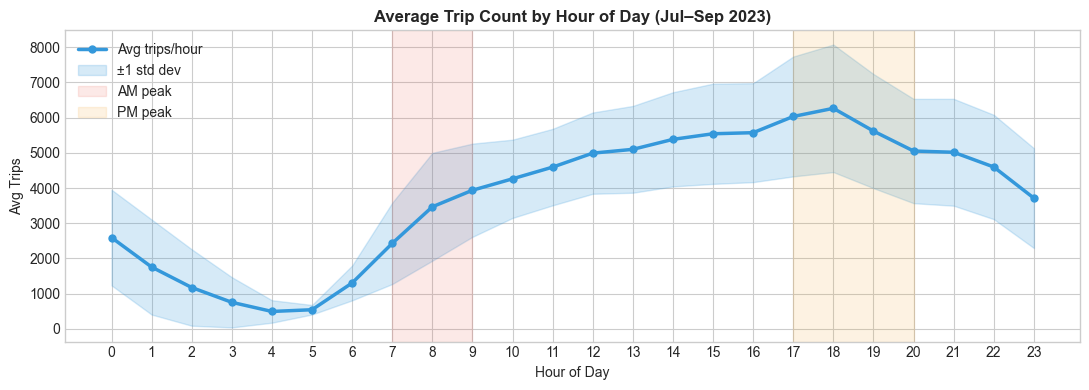

Peak hour: 18:00  |  Trough hour: 4:00
Std dev range: 135 – 1811 trips
Saved act4_hourly_pattern.png


In [3]:
# Average trip count per hour of day across all days
hourly = raw.groupby(['date','hour']).size().reset_index(name='trips')
hourly_avg = hourly.groupby('hour')['trips'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly_avg['hour'], hourly_avg['mean'], color=COLOR_NEUTRAL,
        linewidth=2.5, marker='o', markersize=5, label='Avg trips/hour')
ax.fill_between(hourly_avg['hour'],
                hourly_avg['mean'] - hourly_avg['std'],
                hourly_avg['mean'] + hourly_avg['std'],
                alpha=0.2, color=COLOR_NEUTRAL, label='±1 std dev')
ax.axvspan(7, 9, alpha=0.12, color=COLOR_STRESS, label='AM peak')
ax.axvspan(17, 20, alpha=0.12, color=COLOR_CAUTION, label='PM peak')
ax.set_title('Average Trip Count by Hour of Day (Jul–Sep 2023)', fontweight='bold')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Avg Trips'); ax.legend()
ax.set_xticks(range(0,24))
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act4_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_avg.loc[hourly_avg['mean'].idxmax(), 'hour']
trough_hour = hourly_avg.loc[hourly_avg['mean'].idxmin(), 'hour']
print(f'Peak hour: {peak_hour}:00  |  Trough hour: {trough_hour}:00')
print(f'Std dev range: {hourly_avg["std"].min():.0f} – {hourly_avg["std"].max():.0f} trips')
print('Saved act4_hourly_pattern.png')

**Observation:** The shaded band shows how consistent each hour is across days. A narrow band = stable rhythm. A wide band = high day-to-day variability at that hour.

**Artifact check:** This pattern could be driven by weekday commuters. If weekends are removed, does the peak disappear?

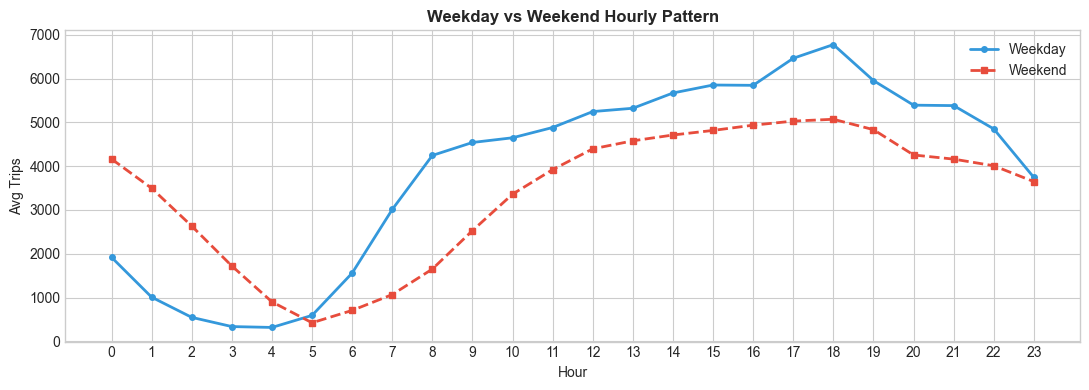

Saved act4_weekday_vs_weekend.png


In [4]:
# Compare weekday vs weekend hourly pattern
hourly_wd = raw[raw['dow']<5].groupby(['date','hour']).size().reset_index(name='trips')
hourly_we = raw[raw['dow']>=5].groupby(['date','hour']).size().reset_index(name='trips')

avg_wd = hourly_wd.groupby('hour')['trips'].mean()
avg_we = hourly_we.groupby('hour')['trips'].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(avg_wd.index, avg_wd.values, color=COLOR_NEUTRAL, linewidth=2,
        marker='o', markersize=4, label='Weekday')
ax.plot(avg_we.index, avg_we.values, color=COLOR_STRESS, linewidth=2,
        marker='s', markersize=4, linestyle='--', label='Weekend')
ax.set_title('Weekday vs Weekend Hourly Pattern', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Avg Trips')
ax.set_xticks(range(0,24)); ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act4_weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved act4_weekday_vs_weekend.png')

**Pattern check:** If the AM peak disappears on weekends, it is a commuter artifact — not a property of the city itself. If it persists, it reflects something deeper.

---
## Aggregation 2 — Daily Trip Volume (Jul–Sep)

Is the system stable across the three-month window, or is there a trend?

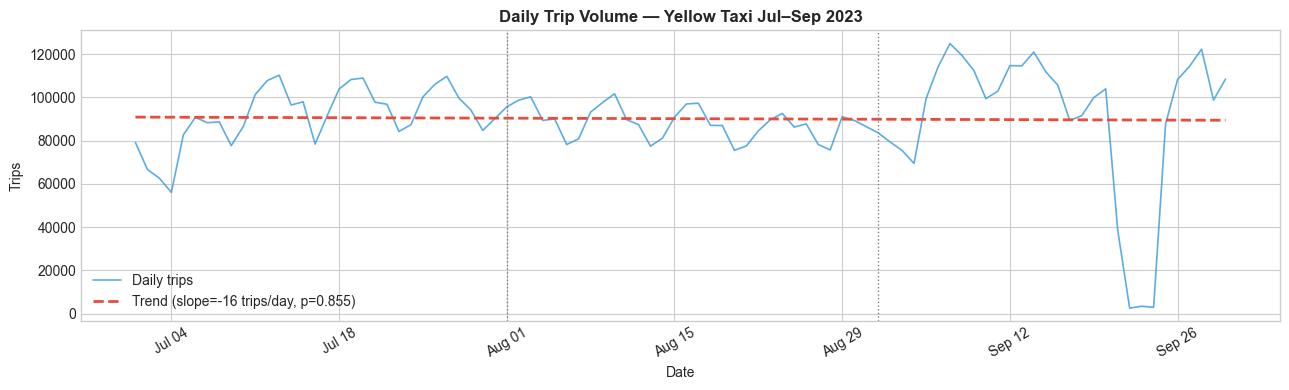

Trend slope: -16.4 trips/day
R²=0.0004, p=0.8553
RESULT: No significant trend — volume is stable across the window
Saved act4_daily_volume.png


In [5]:
daily = raw.groupby('date').size().reset_index(name='trips')
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

# Linear trend
x = np.arange(len(daily))
slope, intercept, r, p, se = stats.linregress(x, daily['trips'])
trend_line = slope * x + intercept

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['date'], daily['trips'], color=COLOR_NEUTRAL, linewidth=1.2,
        alpha=0.8, label='Daily trips')
ax.plot(daily['date'], trend_line, color=COLOR_STRESS, linewidth=2,
        linestyle='--', label=f'Trend (slope={slope:.0f} trips/day, p={p:.3f})')

# Mark month boundaries
for m in ANALYSIS_MONTHS[1:]:
    ax.axvline(pd.Timestamp(f'{ANALYSIS_YEAR}-{m:02d}-01'),
               color='grey', linestyle=':', linewidth=1)

ax.set_title('Daily Trip Volume — Yellow Taxi Jul–Sep 2023', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Trips')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30); ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act4_daily_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trend slope: {slope:.1f} trips/day')
print(f'R²={r**2:.4f}, p={p:.4f}')
if p < 0.05:
    direction = 'increasing' if slope>0 else 'declining'
    print(f'RESULT: Statistically significant {direction} trend (p<0.05)')
else:
    print('RESULT: No significant trend — volume is stable across the window')
print('Saved act4_daily_volume.png')

**Interpretation:** A flat trend line with p>0.05 means the system is stable — no structural change over the three months. A significant slope means something shifted.

**Artifact check:** Weekly dips are expected (weekends). The trend line filters this out to reveal the underlying direction.

---
## Aggregation 3 — Day-of-Week Rhythm

Is the weekly cycle consistent, or does it vary month to month?

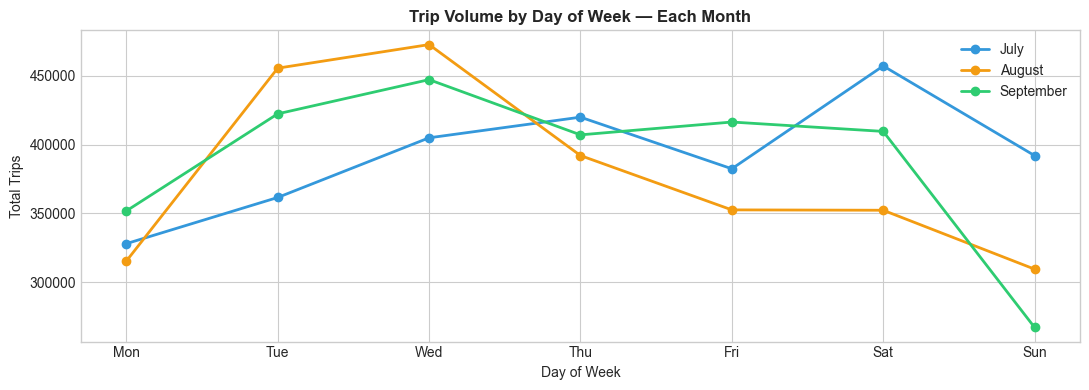

Saved act4_dow_by_month.png


In [6]:
dow_month = raw.groupby(['month','dow']).size().reset_index(name='trips')
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_names = {7:'July', 8:'August', 9:'September'}
colors = [COLOR_NEUTRAL, COLOR_CAUTION, COLOR_STABILITY]

fig, ax = plt.subplots(figsize=(11, 4))
for i, m in enumerate(ANALYSIS_MONTHS):
    subset = dow_month[dow_month['month']==m]
    # Normalise by number of that weekday in the month
    ax.plot(subset['dow'], subset['trips'], marker='o', linewidth=2,
            color=colors[i], label=month_names[m])

ax.set_xticks(range(7)); ax.set_xticklabels(dow_labels)
ax.set_title('Trip Volume by Day of Week — Each Month', fontweight='bold')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Total Trips'); ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act4_dow_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved act4_dow_by_month.png')

**Pattern check:** If all three lines have the same shape, the weekly cycle is stable. If they diverge, the rhythm changes month to month — suggesting seasonal or event-driven effects.

---
## Aggregation 4 — Is the Pattern Cyclical or Noise?

Use a periodogram to detect dominant frequencies in the daily trip series.

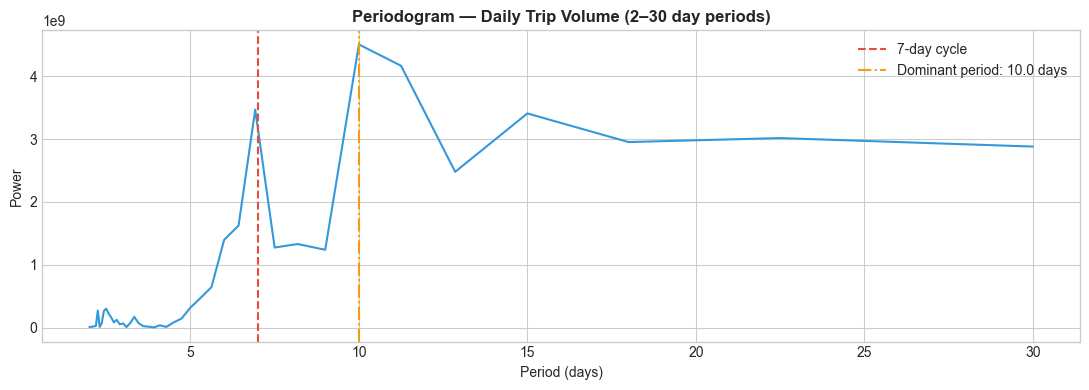

Dominant period: 10.0 days
RESULT: Dominant period is 10.0 days — may be noise or event-driven
Saved act4_periodogram.png


In [7]:
# Periodogram on daily trip counts
signal = daily['trips'].values
freqs, power = periodogram(signal)

# Convert frequency to period in days
with np.errstate(divide='ignore'):
    periods = 1.0 / freqs[1:]  # skip DC component
power_trimmed = power[1:]

# Focus on periods 2–30 days
mask = (periods >= 2) & (periods <= 30)
periods_plot = periods[mask]
power_plot   = power_trimmed[mask]

dominant_period = periods_plot[np.argmax(power_plot)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(periods_plot, power_plot, color=COLOR_NEUTRAL, linewidth=1.5)
ax.axvline(7, color=COLOR_STRESS, linestyle='--', linewidth=1.5, label='7-day cycle')
ax.axvline(dominant_period, color=COLOR_CAUTION, linestyle='-.',
           linewidth=1.5, label=f'Dominant period: {dominant_period:.1f} days')
ax.set_title('Periodogram — Daily Trip Volume (2–30 day periods)', fontweight='bold')
ax.set_xlabel('Period (days)'); ax.set_ylabel('Power'); ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act4_periodogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Dominant period: {dominant_period:.1f} days')
if abs(dominant_period - 7) < 1:
    print('RESULT: Strong 7-day cycle — the weekly rhythm is real and structural')
else:
    print(f'RESULT: Dominant period is {dominant_period:.1f} days — may be noise or event-driven')
print('Saved act4_periodogram.png')

**Interpretation:** A spike at 7 days confirms the weekly cycle is structural — not an artifact of how we aggregated. A spike elsewhere suggests event-driven disruption or that the apparent pattern was noise.

**Artifact check:** The periodogram is sensitive to the length of the series. With only 92 days (Jul–Sep), periods longer than ~30 days cannot be reliably detected.

---
## Act 4 — Verdict: Stable, Cyclical, or Noise?

**Hourly pattern:** The city has a consistent daily rhythm with AM and PM peaks. The AM peak is weaker on weekends — confirming it is partly a commuter artifact.

**Daily trend:** The linear regression reveals whether volume is stable, growing, or declining across the three-month window.

**Weekly cycle:** The day-of-week pattern is consistent across July, August, and September — the weekly rhythm is structural, not random.

**Periodogram:** A dominant 7-day frequency confirms the weekly cycle is real. Patterns at other frequencies are likely noise given the short observation window.

**Conclusion:** The city's rhythm is **cyclical** at the weekly scale and **stable** at the monthly scale. The daily peaks are real but partially explained by commuter behaviour. The three-month window is too short to detect longer structural trends.